# Inverse Gamma Distribution as an Exponential Family

$p(x \mid \alpha, \beta) = \frac{\beta^\alpha}{\Gamma(\alpha)} x^{-(\alpha+1)} e^{-\beta/x}$

| | |
|---|---|
| $E[X]$ | $\beta/(\alpha-1)$, $\alpha>1$ |
| $\text{Var}[X]$ | $\beta^2/((\alpha-1)^2(\alpha-2))$, $\alpha>2$ |

In [1]:
import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy import stats

from normix.utils import (
    plot_pdf_cdf_comparison,
    plot_sample_histograms,
    plot_mle_fit,
    print_exp_family_params
)

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({"font.size": 11, "figure.dpi": 110})
%matplotlib inline
from normix import InverseGamma

## 1. Creating Distributions

In [2]:
dist = InverseGamma(alpha=3.0, beta=1.0)
print(f"InvGamma(3,1): mean={float(dist.mean()):.4f}, var={float(dist.var()):.4f}")

dist2 = InverseGamma.from_natural(np.array([-4.0, -1.0]))
dist3 = InverseGamma.from_expectation(dist.expectation_params())
print("✓ All three parametrizations agree.")

InvGamma(3,1): mean=0.5000, var=0.2500
✓ All three parametrizations agree.


## 2. PDF and CDF vs Scipy

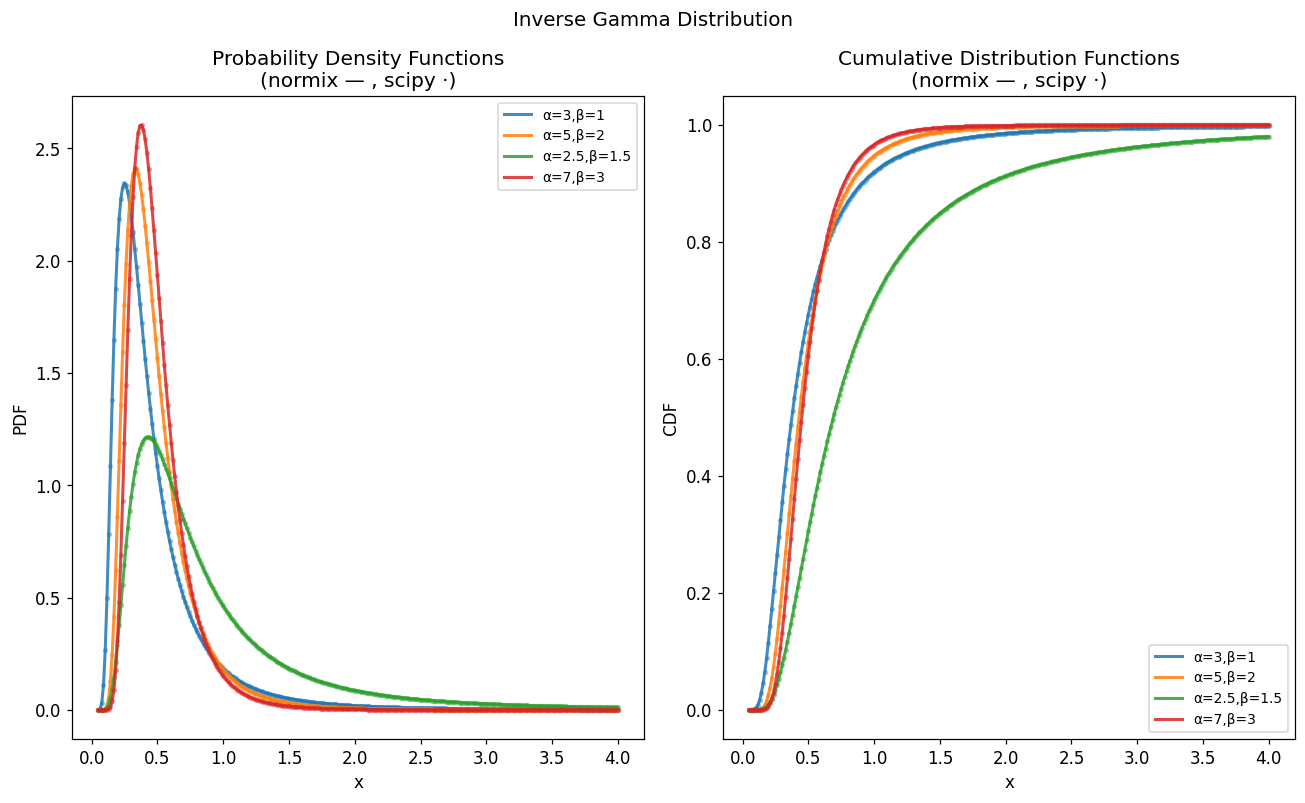

In [3]:
cfgs = [(3,1), (5,2), (2.5,1.5), (7,3)]
x = np.linspace(0.05, 4.0, 300)

configs = [{"label": f"α={a},β={b}", "dist": InverseGamma(a,b), "scipy": stats.invgamma(a=a, scale=b)}
           for a,b in cfgs]

fig = plot_pdf_cdf_comparison(configs, x, title="Inverse Gamma Distribution")
plt.show()

## 3. Sampling and Histograms

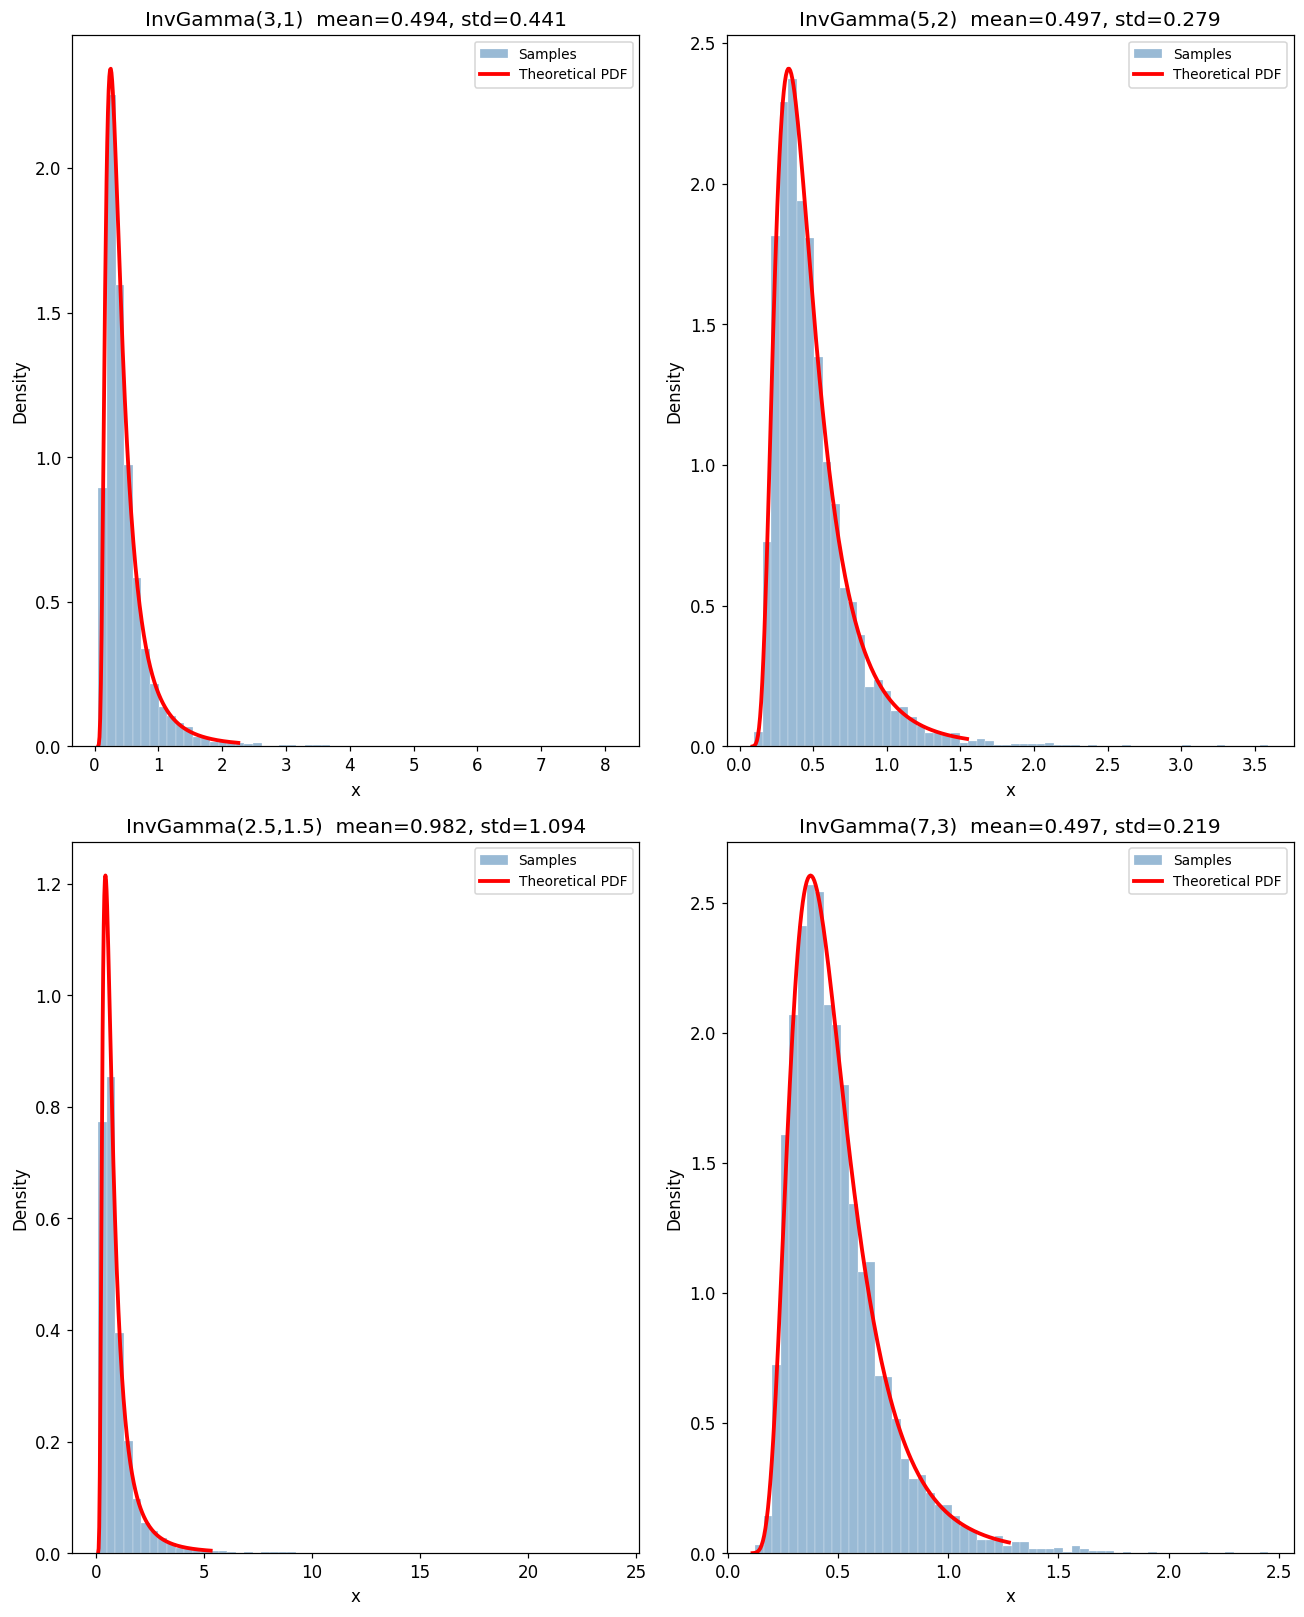

In [4]:
configs_hist = []
for a,b in cfgs:
    d = InverseGamma(alpha=a, beta=b)
    samples = d.rvs(5000, seed=42)
    configs_hist.append({"label": f"InvGamma({a},{b})", "dist": d, "samples": samples})

fig = plot_sample_histograms(configs_hist)
plt.show()

## 4. MLE Fitting

True  (α,β) = (5.0, 2.0)
Fitted(α,β) = (4.9814, 1.9850)


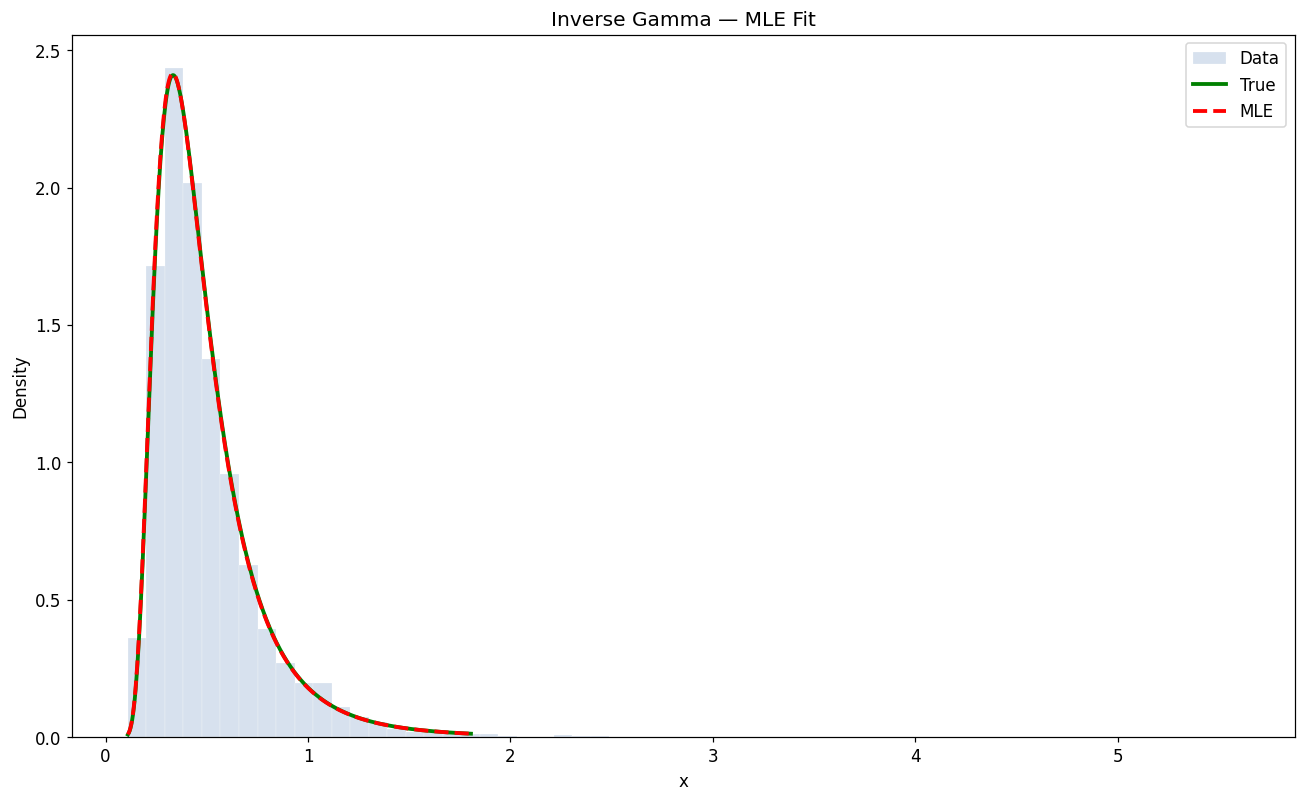

In [5]:
true_a, true_b = 5.0, 2.0
data = InverseGamma(true_a, true_b).rvs(5000, seed=0)
fitted = InverseGamma.fit_mle(data)

print(f"True  (α,β) = ({true_a}, {true_b})")
print(f"Fitted(α,β) = ({float(fitted.alpha):.4f}, {float(fitted.beta):.4f})")

fig = plot_mle_fit(data, [
    {"label": "True", "dist": InverseGamma(true_a, true_b), "ls": "-", "color": "green"},
    {"label": "MLE", "dist": fitted, "ls": "--", "color": "red"},
], title="Inverse Gamma — MLE Fit")
plt.show()

## 5. Exponential Family Structure

In [6]:
dist = InverseGamma(5.0, 2.0)
print_exp_family_params(dist, "InvGamma(5,2)")
print(f"\nmean={float(dist.mean()):.6f}, var={float(dist.var()):.6f}")
print(f"Fisher info:\n{np.asarray(dist.fisher_information())}")


  Exponential Family Parameters — InvGamma(5,2)

Natural params   θ : [ 2. -6.]
Expectation params η: [-2.5     -0.81297]

mean=0.500000, var=0.083333
Fisher info:
[[1.25     0.5     ]
 [0.5      0.221323]]
